<a href="https://colab.research.google.com/github/Nandhini987/Stellaria-Rag-Chatbot/blob/main/Photometric_Redshift_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import math
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

Load data (skip initial metadata header line)

In [37]:

df = pd.read_csv("dataset.csv", skiprows=1)
print(df.head())
print(df.shape)
print(df.describe())
print(df.info())


                 objid           specobjid    z_spec  z_spec_err  zWarning  \
0  1237645879578460271  466232818830174208  0.048765    0.000014         0   
1  1237645943976493287  465166016868018176  0.226707    0.000010         0   
2  1237648674510996239  330051153884637184  0.419593    0.000087         0   
3  1237648674530263512  386334054649194496  0.156045    0.000032         0   
4  1237648675067134474  386341476352681984  0.118532    0.000026         0   

    class   dered_u   dered_g   dered_r   dered_i   dered_z  modelMagErr_u  \
0  GALAXY  18.26087  17.02536  16.56240  16.33304  16.15742       0.027798   
1  GALAXY  20.84448  19.64851  18.90195  18.57236  18.39260       0.130325   
2  GALAXY  22.42309  20.69038  18.93546  18.25295  17.87946       0.557268   
3  GALAXY  19.89742  17.98469  17.04307  16.63145  16.27837       0.117230   
4  GALAXY  20.21570  18.02127  16.98972  16.56370  16.16975       0.089915   

   modelMagErr_g  modelMagErr_r  modelMagErr_i  modelMagErr_z 

In [38]:
# 2. Automated column grouping via regex
id_cols      = df.filter(regex=r'id$').columns.tolist()
mag_cols     = df.filter(regex=r'^dered_').columns.tolist()
err_cols     = df.filter(regex=r'Err|_err$').columns.tolist()
morph_cols   = df.filter(regex=r'^petro').columns.tolist()

# Define ground-truth target and metadata
target_col   = 'z_spec'
quality_cols = ['zWarning', 'class']

In [39]:
# 3. Coerce numeric columns to float (convert text artifacts/sentinels to NaN)
numeric_cols = mag_cols + err_cols + morph_cols + [target_col,'zWarning']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [40]:
# 4. Handle SDSS database sentinels (replace values < 0 or > 35 in magnitudes with NaN)
for col in mag_cols:
    df.loc[(df[col] < 0) | (df[col] > 35), col] = np.nan

In [41]:
# 5. Apply astronomical quality filters

clean_mask = (
    #Target Validation
    # Restrict strictly to galaxies: stars have z≈0 (non-cosmological) and quasars (QSOs) follow non-stellar power-law SEDs
    (df['class'] == 'GALAXY') &
    (df['zWarning'] == 0) &
    (df[target_col].between(0.001, 1.0)) &


    #2. Photometric Detection & Non-Saturation Limits
    (df['dered_u'].between(12.0, 26.0)) &
    (df['dered_g'].between(12.0, 25.0)) &
    (df['dered_r'].between(12.0, 24.0)) &
    (df['dered_i'].between(12.0, 24.0)) &
    (df['dered_z'].between(12.0, 23.0)) &

    # 3. Morphological & Signal-to-Noise Verification
    (df['petroR50_r'] > 0) &
    (df['petroR90_r'] > 0) &
    (df['modelMagErr_r'] > 0) &
    (df['modelMagErr_r'] < 0.3)
)


In [42]:
# 6. Extract cleaned dataset
df_clean = df[clean_mask].dropna(subset=numeric_cols).copy()
print(f"Original records: {len(df)} | Clean records: {len(df_clean)}")



Original records: 50000 | Clean records: 49471


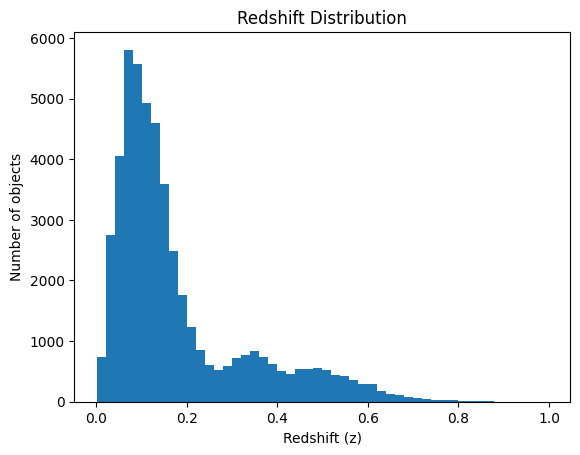

In [43]:

plt.hist(df_clean['z_spec'], bins=50)
plt.xlabel('Redshift (z)')
plt.ylabel('Number of objects')
plt.title('Redshift Distribution')
plt.show()

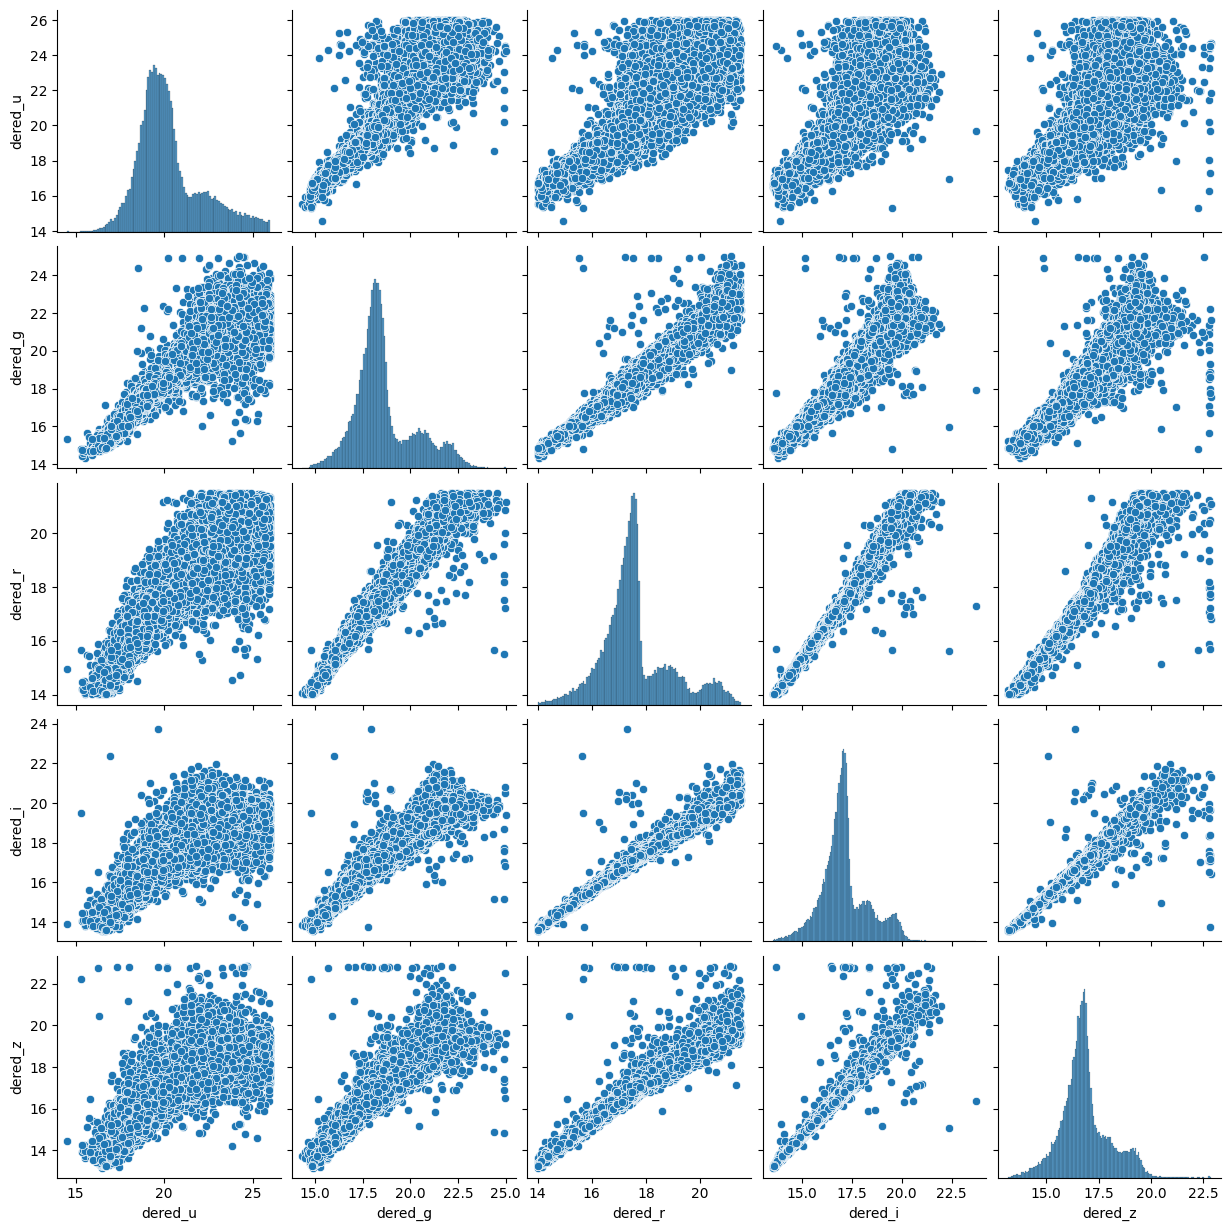

In [44]:
sns.pairplot(df_clean[mag_cols])
plt.show()

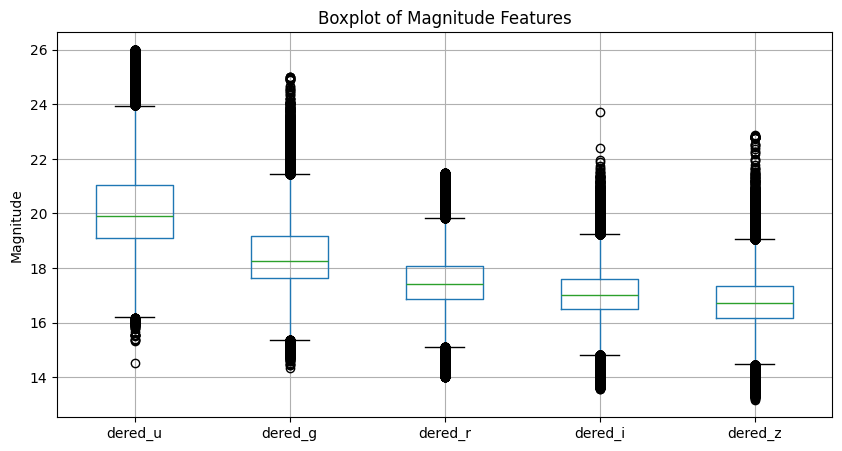

In [45]:
df_clean[mag_cols].boxplot(
    figsize=(10, 5)
)

plt.title("Boxplot of Magnitude Features")
plt.ylabel("Magnitude")
plt.show()

In [46]:
#  Feature Engineering on df_clean

df_clean['u_g'] = df_clean['dered_u'] - df_clean['dered_g']
df_clean['g_r'] = df_clean['dered_g'] - df_clean['dered_r']
df_clean['r_i'] = df_clean['dered_r'] - df_clean['dered_i']
df_clean['i_z'] = df_clean['dered_i'] - df_clean['dered_z']


# Define feature list (colors + magnitudes + morphological features)
feature_cols = mag_cols+morph_cols+['u_g', 'g_r', 'r_i', 'i_z',]

X = df_clean[feature_cols]
y = df_clean['z_spec'].values


In [47]:
df_clean[['u_g', 'g_r', 'r_i', 'i_z']].describe()

,u_g,g_r,r_i,i_z
count,49471.000000,49471.000000,49471.000000,49471.000000
mean,1.712336,0.988383,0.466621,0.295621
std,0.726398,0.452160,0.209955,0.191039
min,-5.864840,-2.172810,-6.742030,-9.094120
25%,1.269460,0.689875,0.368730,0.244330
50%,1.700210,0.912160,0.424020,0.315560
75%,1.966480,1.207910,0.505770,0.359755
max,8.968110,9.376550,2.301600,7.337050


In [48]:
# Split into Train / Validation / Test sets (70% / 15% / 15%)
X = df_clean[numeric_cols].drop(columns=[target_col])
y = df_clean[target_col].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, shuffle=True
)

print("-" * 45)
print(f"X_train shape: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val shape:   {X_val.shape} | y_val:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape} | y_test:  {y_test.shape}")

---------------------------------------------
X_train shape: (34629, 14) | y_train: (34629,)
X_val shape:   (7421, 14) | y_val:   (7421,)
X_test shape:  (7421, 14) | y_test:  (7421,)


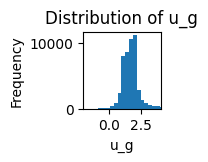

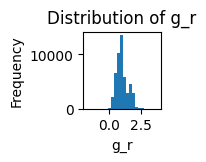

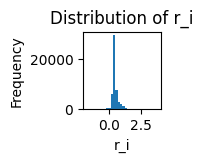

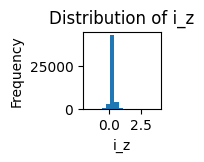

In [49]:
color_cols = ['u_g', 'g_r', 'r_i', 'i_z']

for col in color_cols:
    plt.figure(figsize=(1,1))
    plt.hist(df_clean[col], bins=50)
    plt.xlim(-2,4)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.show()

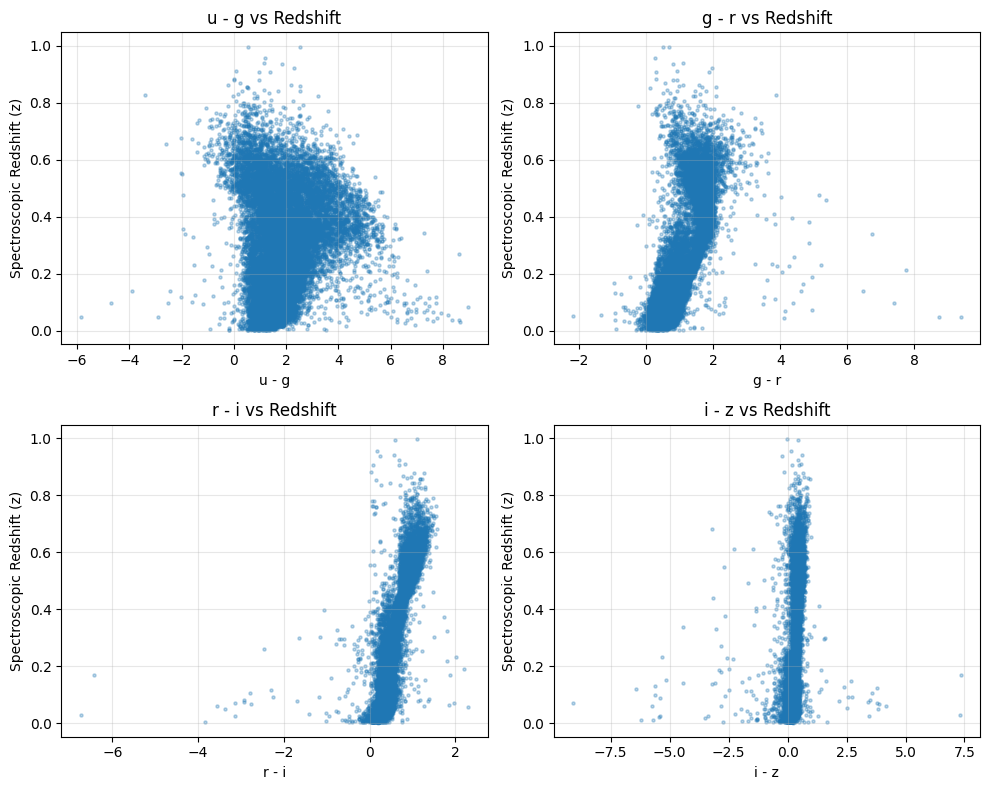

In [50]:
labels = ['u - g', 'g - r', 'r - i', 'i - z']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, col, label in zip(axes.flatten(), color_cols, labels):
    ax.scatter(df_clean[col], df_clean['z_spec'], s=5, alpha=0.3)

    ax.set_xlabel(label)
    ax.set_ylabel('Spectroscopic Redshift (z)')
    ax.set_title(f'{label} vs Redshift')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
#Ridge Regression

scaler=RobustScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_val_scaled=scaler.transform(X_val)
X_test_scaler=scaler.transform(X_test)

ridge=Ridge(alpha=1.0)
ridge.fit(X_train_scaled,y_train)
y_pred_rr=ridge.predict(X_val_scaled)
print(y_pred_rr)

[0.0890362  0.20979947 0.09059205 ... 0.16025778 0.05345131 0.12282015]


In [52]:
#RandomForest

rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_val)
print(y_pred_rf)

[0.08574454 0.22336403 0.09624994 ... 0.15752321 0.0809295  0.1040696 ]


In [53]:
#XGBoost
xgb_untuned=xgb.XGBRegressor(n_estimators=100,max_depth=8,random_state=42,learning_rate=0.1)
xgb_untuned.fit(X_train,y_train)
y_pred_xgb=xgb_untuned.predict(X_val)
print(y_pred_xgb)

[0.0876533  0.22116542 0.10017859 ... 0.1602038  0.05949869 0.10172369]


In [54]:
#comparison
models={
    'ridge':y_pred_rr,
    'random_forest':y_pred_rf,
    'xgboost':y_pred_xgb
}
print(f"{'Model':>15}{'MAE':>20}{'RMSE':>20}{'R2':>20}")
print('-*'*40)
for model,y_pred in models.items():
  mae=mean_absolute_error(y_val,y_pred)
  rmse=math.sqrt(mean_squared_error(y_val,y_pred))
  r2=r2_score(y_val,y_pred)

  print(f"{model:>15}{mae:>20.4f}{rmse:>20.4f}{r2:>20.4f}")


          Model                 MAE                RMSE                  R2
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
          ridge              0.0316              0.0488              0.8936
  random_forest              0.0232              0.0369              0.9392
        xgboost              0.0228              0.0366              0.9402


In [55]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.03, 0.05, 0.08],
    'max_depth': [8,10,12],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'reg_alpha': [0.0, 0.1, 1.0],
    'reg_lambda': [1.0, 5.0, 10.0]
}

xgb_base = xgb.XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror')

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=25,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(f"Best Parameters: {random_search.best_params_}")
best_xgb = random_search.best_estimator_

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Parameters: {'subsample': 0.85, 'reg_lambda': 10.0, 'reg_alpha': 0.1, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [56]:
# Predict on validation data
y_val_pred_tuned = best_xgb.predict(X_val)

# Calculate metrics
mae = mean_absolute_error(y_val, y_val_pred_tuned)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_tuned))
r2 = r2_score(y_val, y_val_pred_tuned)

print("Tuned XGBoost Results On Validation Set")
print("-"*50)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Tuned XGBoost Results On Validation Set
--------------------------------------------------
MAE  : 0.0219
RMSE : 0.0352
R²   : 0.9447


In [57]:

# Predict on test data
y_test_pred_tuned = best_xgb.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_test_pred_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned))
r2 = r2_score(y_test, y_test_pred_tuned)

print("Final Tuned XGBoost Test Results")
print("-" * 50)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Final Tuned XGBoost Test Results
--------------------------------------------------
MAE  : 0.0209
RMSE : 0.0330
R²   : 0.9515


In [58]:
# Untuned XGBoost - test predictions
y_test_pred_untuned = xgb_untuned.predict(X_test)
# Tuned XGBoost - test predictions
y_test_pred_tuned = best_xgb.predict(X_test)


# Untuned
mae_untuned = mean_absolute_error(y_test, y_test_pred_untuned)
rmse_untuned = np.sqrt(mean_squared_error(y_test, y_test_pred_untuned))
r2_untuned = r2_score(y_test, y_test_pred_untuned)

# Tuned
mae_tuned = mean_absolute_error(y_test, y_test_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned))
r2_tuned = r2_score(y_test, y_test_pred_tuned)

print("XGBoost: Tuned vs Untuned")
print("-" * 50)
print(f"{'Metric':<10} {'Untuned':<12} {'Tuned':<12}")
print(f"{'MAE':<10} {mae_untuned:<12.4f} {mae_tuned:<12.4f}")
print(f"{'RMSE':<10} {rmse_untuned:<12.4f} {rmse_tuned:<12.4f}")
print(f"{'R²':<10} {r2_untuned:<12.4f} {r2_tuned:<12.4f}")

XGBoost: Tuned vs Untuned
--------------------------------------------------
Metric     Untuned      Tuned       
MAE        0.0217       0.0209      
RMSE       0.0336       0.0330      
R²         0.9497       0.9515      


In [59]:
# Calculate residuals
residuals = y_test - y_test_pred_tuned

print("Residual Statistics")
print("-" * 50)
print(f"Mean Residual : {np.mean(residuals):.4f}")
print(f"Std Residual  : {np.std(residuals):.4f}")
print(f"Min Residual  : {np.min(residuals):.4f}")
print(f"Max Residual  : {np.max(residuals):.4f}")

Residual Statistics
--------------------------------------------------
Mean Residual : -0.0005
Std Residual  : 0.0330
Min Residual  : -0.4341
Max Residual  : 0.5735


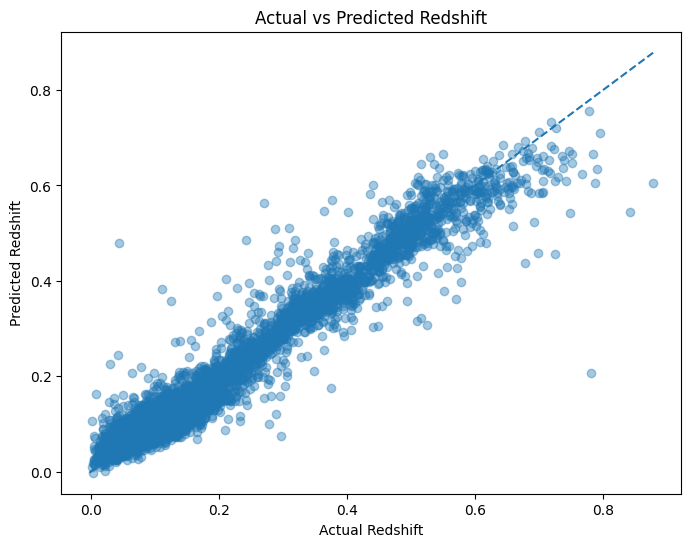

In [60]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred_tuned, alpha=0.4)

min_val = min(y_test.min(), y_test_pred_tuned.min())
max_val = max(y_test.max(), y_test_pred_tuned.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Redshift")
plt.ylabel("Predicted Redshift")
plt.title("Actual vs Predicted Redshift")

plt.show()

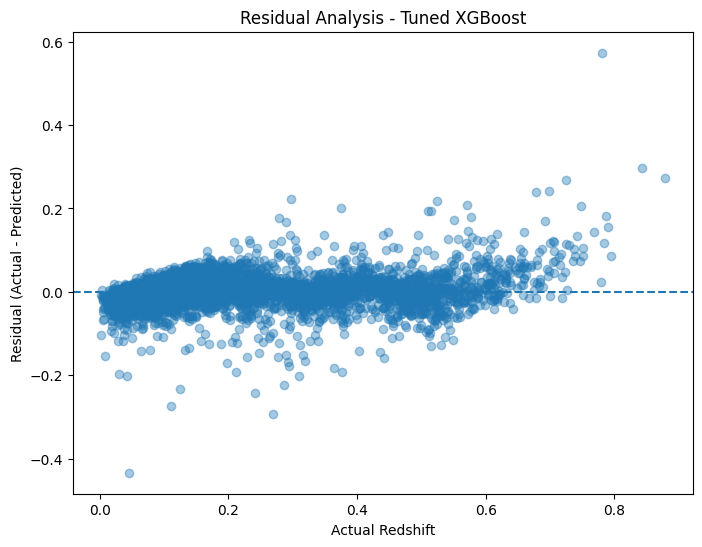

In [61]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, residuals, alpha=0.4)

plt.axhline(0, linestyle="--")

plt.xlabel("Actual Redshift")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Analysis - Tuned XGBoost")

plt.show()

In [62]:
results = []

bins = [0, 0.1, 0.2, 0.3, 0.4, 0.6, np.inf]
labels = ["0–0.1", "0.1–0.2", "0.2–0.3", "0.3–0.4", "0.4–0.6", ">0.6"]

redshift_bins = pd.cut(y_test, bins=bins, labels=labels)

for label in labels:
    mask = redshift_bins == label

    actual = y_test[mask]
    predicted = y_test_pred_tuned[mask]

    if len(actual) > 0:
        mae = mean_absolute_error(actual, predicted)
        rmse = np.sqrt(mean_squared_error(actual, predicted))

        results.append({
            "Redshift Range": label,
            "Samples": len(actual),
            "MAE": mae,
            "RMSE": rmse
        })

error_by_redshift = pd.DataFrame(results)

print(error_by_redshift)

  Redshift Range  Samples       MAE      RMSE
0          0–0.1     2781  0.016893  0.024749
1        0.1–0.2     2676  0.016884  0.024152
2        0.2–0.3      591  0.029638  0.046451
3        0.3–0.4      537  0.025305  0.037976
4        0.4–0.6      683  0.032663  0.045758
5           >0.6      153  0.062498  0.093252


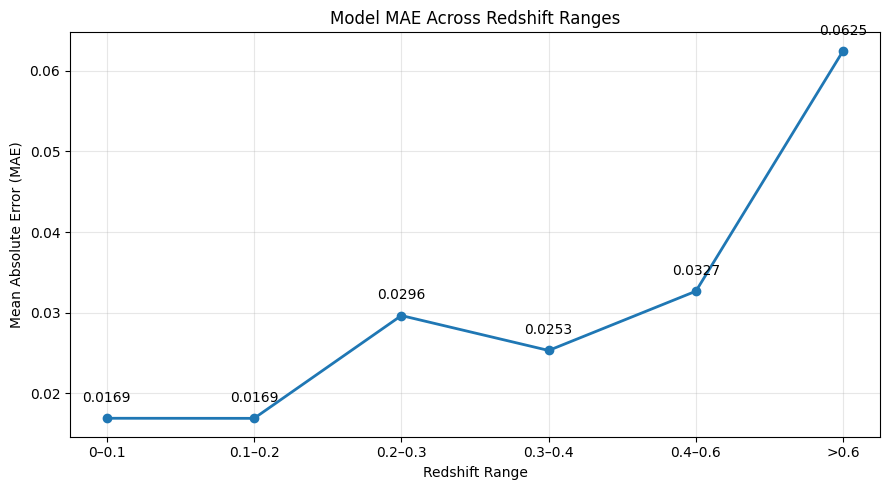

In [63]:
plt.figure(figsize=(9, 5))

plt.plot(
    error_by_redshift["Redshift Range"],
    error_by_redshift["MAE"],
    marker="o",
    linewidth=2
)

# Add MAE values above each point
for i, value in enumerate(error_by_redshift["MAE"]):
    plt.text(
        i,
        value + 0.002,
        f"{value:.4f}",
        ha="center"
    )

plt.xlabel("Redshift Range")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("Model MAE Across Redshift Ranges")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("mae_vs_redshift_range.png", dpi=300, bbox_inches="tight")

plt.show()

## Key Findings

- Tree-based models significantly outperformed Ridge Regression.
- Random Forest and XGBoost achieved R² values of approximately 0.93.
- Hyperparameter tuning was performed to improve XGBoost performance.
- Prediction error was relatively low for redshifts below 0.2.
- Model performance generally degraded at higher redshifts, particularly beyond z > 0.4.
- The higher error at large redshifts is partly associated with the smaller number of high-redshift samples.


## Conclusion

The results demonstrate that photometric features, particularly magnitude-based color indices, can be used to estimate galaxy redshift using machine learning. Among the evaluated models, tree-based ensemble methods performed substantially better than the linear Ridge baseline. The redshift-range analysis also showed that prediction accuracy decreases for less-represented, higher-redshift galaxies.
